[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter17_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 17: Bubbles and Crashes

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 17: simulated rational bubbles, nine historical run-ups, Bubbles for Fama on 49 US industries, GSADF/BSADF tests, LPPLS fits and Markov-switching regimes.

In [1]:
# On Colab: !pip install xlrd
import io
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import optimize, stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'

HERE = '.'
SEED = 42
R_MC = 2000
RECOMPUTE = False   # True: recalculeaza indicatorii LPPLS (cateva minute); False: ii citeste din fisierele publicate
QL_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_17/'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend(fig, axes, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer, np.bool_)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o.date())
    return o


def yrs(idx):
    """Data -> ani zecimali."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25)


def todate(x):
    """Ani zecimali -> data."""
    y = int(np.floor(x))
    return pd.Timestamp(f'{y}-01-01') + pd.Timedelta(days=float((x - y) * 365.25))


def d2s(d):
    return None if d is None else str(pd.Timestamp(d).date())


import shutil
import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder
# published LPPLS indicators: local copy if the notebook runs inside the repository
for _d in ('.', os.path.join('..', 'Quantlets', 'Ch_17'), os.path.join('..', '..', 'Quantlets', 'Ch_17')):
    for _f in ('ch17_lppls_ci_btc.csv', 'ch17_lppls_ci_ndx.csv'):
        if os.path.exists(os.path.join(_d, _f)) and not os.path.exists(os.path.join(HERE, _f)):
            shutil.copy(os.path.join(_d, _f), HERE)


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026 (Nasdaq 100, S&P 500, BET, BET-FI, Bitcoin, Ethereum, Dogecoin, NVIDIA, Cisco, Tesla, GameStop, Strategy).
- Weekly and monthly series: last close of the week or month; stocks adjusted for dividends and splits.
- S&P Composite monthly since 1871 (Robert J. Shiller); 49 US industry portfolios (Kenneth French Data Library).

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, coloana, data de start)
MARKETS = {
    'sp500': ('GSPC.INDX',   'S&P 500',        'index',  'close',          '1990-01-01'),
    'ndx':   ('NDX.INDX',    'Nasdaq 100',     'index',  'close',          '1990-01-01'),
    'bet':   ('BET',         'BET',            'index',  'close',          '1997-09-19'),
    'betfi': ('BETFI.INDX',  'BET-FI',         'index',  'close',          '2012-01-25'),
    'btc':   ('BTC-USD.CC',  'Bitcoin',        'crypto', 'close',          '2014-09-17'),
    'eth':   ('ETH-USD.CC',  'Ethereum',       'crypto', 'close',          '2016-01-01'),
    'doge':  ('DOGE-USD.CC', 'Dogecoin',       'crypto', 'close',          '2017-01-01'),
    'nvda':  ('NVDA.US',     'NVIDIA',         'stock',  'adjusted_close', '1999-01-22'),
    'csco':  ('CSCO.US',     'Cisco Systems',  'stock',  'adjusted_close', '1990-02-16'),
    'tsla':  ('TSLA.US',     'Tesla',          'stock',  'adjusted_close', '2010-06-29'),
    'gme':   ('GME.US',      'GameStop',       'stock',  'adjusted_close', '2002-02-13'),
    'mstr':  ('MSTR.US',     'Strategy (MicroStrategy)', 'stock', 'adjusted_close', '1998-06-11'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

SHILLER_URLS = ['https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/ie_data.xls',
                'http://www.econ.yale.edu/~shiller/data/ie_data.xls']
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(name, freq='D', start=None, end=END):
    """Nivelul seriei: 'D' zilnic (curatat), 'W' ultimul pret al saptamanii, 'M' ultimul pret al lunii."""
    symbol, _, kind, col, start0 = MARKETS[name]
    s = read_market(symbol)[col].loc[start or start0:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    if freq == 'W':
        s = s.resample('W-FRI').last().dropna()
    elif freq == 'M':
        s = s.resample('ME').last().dropna()
    return s.rename(name)


def shiller():
    """S&P Composite lunar (Shiller): pret real, dividend real si raportul pret/dividend (P/D)."""
    if 'shiller' in _CACHE:
        return _CACHE['shiller']
    raw = None
    for url in SHILLER_URLS:
        try:
            raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                         timeout=120).read()
            break
        except Exception:
            continue
    d = pd.read_excel(io.BytesIO(raw), sheet_name='Data', header=None, skiprows=8)
    d = d.iloc[:, [0, 1, 2, 7, 8]]
    d.columns = ['date', 'P', 'D', 'real_P', 'real_D']
    d = d[pd.to_numeric(d['date'], errors='coerce').notna()].copy()
    yr = d['date'].astype(float)
    year = np.floor(yr + 1e-9).astype(int)
    month = np.round((yr - year) * 100).astype(int)
    d.index = pd.to_datetime(dict(year=year, month=month, day=1)) + pd.offsets.MonthEnd(0)
    d = d[['P', 'D', 'real_P', 'real_D']].apply(pd.to_numeric, errors='coerce').dropna()
    d['PD'] = d['real_P'] / d['real_D']
    _CACHE['shiller'] = d
    return d


def _french_table(fname):
    """Primul tabel lunar (YYYYMM) dintr-un fisier Kenneth French, in zecimal."""
    raw = urllib.request.urlopen(urllib.request.Request(FRENCH + fname, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    text = zipfile.ZipFile(io.BytesIO(raw)).read(zipfile.ZipFile(io.BytesIO(raw)).namelist()[0]).decode('latin-1')
    lines = text.splitlines()
    i = next(k for k, l in enumerate(lines) if l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != 6 or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.set_index('date').replace([-99.99, -999.0], np.nan) / 100.0


def industries():
    """49 de industrii (randamente lunare ponderate cu valoarea) si randamentul pietei (Mkt-RF + RF)."""
    if 'ind' in _CACHE:
        return _CACHE['ind']
    ind = _french_table('49_Industry_Portfolios_CSV.zip')
    ff = _french_table('F-F_Research_Data_Factors_CSV.zip')
    mkt = (ff['Mkt-RF'] + ff['RF']).rename('MKT')
    _CACHE['ind'] = (ind, mkt)
    return ind, mkt

## Explosiveness tests, LPPLS and drawdowns

- `psy`, `psy_cv`, `wild_cv`, `episodes`: right-tailed ADF, SADF, GSADF, BSADF, Monte Carlo and wild bootstrap critical values, date-stamping.
- `lppls_fit`, `lppls_qualified`, `lppls_confidence`: LPPLS calibration (Filimonov–Sornette), filter, confidence indicator.

In [4]:
def _cums(y):
    """Sume cumulate pentru regresia Delta y_t = a + b y_{t-1} (randurile t = 1..n); y poate fi (n+1,) sau (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """Statistica t a lui b pentru ferestrele [s, e] (s vector), pe toate replicile (randurile lui C)."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_stat(y):
    """ADF la dreapta pe intreaga serie (fara lag-uri)."""
    C = _cums(y)
    n = len(y) - 1
    return float(_adf_end(C, n - 1, np.array([0]))[0, 0])


def min_window(T, r0=None):
    """Fereastra minima PSY: r0 = 0.01 + 1.8 / sqrt(T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), r0


def psy(y, r0=None):
    """ADF, SADF, GSADF si sirurile BSADF (sup pe inceputuri) si ADF recursiv (PWY) pentru y (log-nivel)."""
    y = np.asarray(y, float)
    n = len(y) - 1                                  # numarul de randuri de regresie
    w0, r0 = min_window(n, r0)
    C = _cums(y)
    bsadf = np.full(n, np.nan)
    fwd = np.full(n, np.nan)
    for e in range(w0 - 1, n):
        s = np.arange(0, e - w0 + 2)
        st = _adf_end(C, e, s)[0]
        bsadf[e] = st.max()
        fwd[e] = st[0]
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)),
                bsadf=bsadf, fwd=fwd, w0=w0, r0=r0, n=n)


def _null_paths(T, R, rng):
    """Mers aleator cu drift slab (PSY 2015): y_t = T^{-1} + y_{t-1} + e_t, e_t ~ N(0, 1)."""
    e = rng.standard_normal((R, T))
    return np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + e, axis=1)], axis=1)


def _bsadf_paths(Y, w0, chunk=100):
    """Sirurile BSADF si ADF recursiv pentru mai multe traiectorii (randurile lui Y)."""
    R, n = Y.shape[0], Y.shape[1] - 1
    bs = np.full((R, n), np.nan)
    fw = np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, n):
            st = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = st.max(axis=1)
            fw[i:i + chunk, e] = st[:, 0]
    return bs, fw


def psy_cv(T, w0, R=1000, seed=42, q=(0.90, 0.95, 0.99)):
    """Valori critice Monte Carlo: ADF, SADF, GSADF (cuantile) si sirurile BSADF / ADF recursiv la 95%."""
    rng = np.random.default_rng(seed)
    bs, fw = _bsadf_paths(_null_paths(T, R, rng), w0)
    out = dict(T=T, w0=w0, R=R,
               adf={f'{int(100 * a)}': float(np.quantile(fw[:, -1], a)) for a in q},
               sadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(fw, axis=1), a)) for a in q},
               gsadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(bs, axis=1), a)) for a in q})
    out['bsadf95'] = np.nanquantile(bs, 0.95, axis=0)
    out['fwd95'] = np.nanquantile(fw, 0.95, axis=0)
    out['null'] = dict(adf=fw[:, -1], sadf=np.nanmax(fw, axis=1), gsadf=np.nanmax(bs, axis=1))
    return out


def wild_cv(y, w0, R=500, seed=42):
    """Wild bootstrap (semne Rademacher pe Delta y, fara drift): sirul BSADF la 95% si GSADF la 95%."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    dy = dy - dy.mean()
    W = rng.choice([-1.0, 1.0], size=(R, len(dy)))
    Y = np.concatenate([np.zeros((R, 1)), np.cumsum(W * dy, axis=1)], axis=1)
    bs, _ = _bsadf_paths(Y, w0)
    return dict(bsadf95=np.nanquantile(bs, 0.95, axis=0), gsadf95=float(np.quantile(np.nanmax(bs, axis=1), 0.95)))


def episodes(stat, cv, index, min_len):
    """Episoade in care stat > cv cel putin min_len perioade: (inceput, sfarsit) datat in timp real."""
    above = np.asarray(stat > cv)
    above[np.isnan(stat) | np.isnan(cv)] = False
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((index[i], index[j] if j + 1 < n else None, j - i + 1))
            i = j + 1
        else:
            i += 1
    return out


# =============================================================================
# BULE RATIONALE SIMULATE
# =============================================================================
def blanchard_watson(T=400, r=0.01, pi=0.97, b0=1.0, sd=0.5, seed=7):
    """Bula Blanchard-Watson: supravietuieste cu prob. pi si creste cu (1+r)/pi, altfel revine la zgomot."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def evans_bubble(T=400, r=0.02, alpha=1.0, delta=0.5, pi=0.85, seed=11):
    """Bula care se prabuseste periodic (Evans 1991): creste cu (1+r) sub alpha, apoi explodeaza sau revine la delta."""
    rng = np.random.default_rng(seed)
    u = np.exp(rng.normal(-0.005, 0.07, T))       # u_t > 0, E[u_t] ~ 1
    B = np.empty(T)
    B[0] = delta
    for t in range(1, T):
        if B[t - 1] <= alpha:
            B[t] = (1 + r) * B[t - 1] * u[t]
        else:
            theta = rng.random() < pi
            B[t] = (delta + (1 + r) / pi * (B[t - 1] - delta / (1 + r)) * theta) * u[t]
    return B


# =============================================================================
# LPPLS (Johansen-Ledoit-Sornette, calibrarea Filimonov-Sornette 2013)
# =============================================================================
def lppls_linear(t, y, tc, m, w):
    """Pentru (tc, m, omega) dati: A, B, C1, C2 prin MCO si suma patratelor reziduurilor; dt = |tc - t|."""
    dt = np.abs(tc - t) + 1e-9
    f = dt ** m
    X = np.column_stack([np.ones_like(t), f, f * np.cos(w * np.log(dt)), f * np.sin(w * np.log(dt))])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _grid_ssr(t, y, tcs, ms, ws):
    """SSR pe o grila (tc, m, omega), vectorizat."""
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.abs(TC[:, None] - t[None, :]) + 1e-9
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, ssr


LPPLS_SEARCH = dict(tc=(-0.2, 0.5), m=(0.01, 0.99), w=(2.0, 25.0))
LPPLS_FILTER = dict(tc=(-0.05, 0.1), m=(0.01, 0.99), w=(2.0, 15.0), osc=2.5, damping=0.5)


def lppls_fit(t, y, tc_rng=LPPLS_SEARCH['tc'], m_rng=LPPLS_SEARCH['m'], w_rng=LPPLS_SEARCH['w'], refine=True):
    """Calibrare LPPLS pe fereastra (t, y), t in ani: grila pe (tc, m, omega) + rafinare Nelder-Mead.
    tc cauta in [t2 + tc_rng[0] * D, t2 + tc_rng[1] * D], D = t2 - t1 (Filimonov-Sornette 2013)."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + tc_rng[0] * D, m_rng[0], w_rng[0]])
    hi = np.array([t2 + tc_rng[1] * D, m_rng[1], w_rng[1]])
    TC, M, W, ssr = _grid_ssr(t, y, np.linspace(lo[0], hi[0], 21), np.linspace(lo[1], hi[1], 10),
                              np.linspace(lo[2], hi[2], 12))
    k = int(np.argmin(ssr))
    x0 = np.array([TC[k], M[k], W[k]])
    if refine:
        obj = lambda p: lppls_linear(t, y, *np.clip(p, lo, hi))[1]
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-9, maxiter=800))
        x0 = np.clip(r.x, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppls_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2),
                C=float(C), ssr=float(s), rmse=float(np.sqrt(s / len(t))),
                damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / (2 * np.pi) * np.log(abs((tc - t1) / (tc - t2)))),
                t1=float(t1), t2=float(t2))


def lppls_path(fit, t):
    """Traiectoria LPPLS ajustata (log-pret)."""
    dt = np.abs(fit['tc'] - np.asarray(t, float)) + 1e-9
    f = dt ** fit['m']
    return fit['A'] + fit['B'] * f + f * (fit['C1'] * np.cos(fit['w'] * np.log(dt)) + fit['C2'] * np.sin(fit['w'] * np.log(dt)))


def lppls_qualified(fit, flt=LPPLS_FILTER):
    """Filtrul de calificare: bula pozitiva (B < 0), m si omega in interval, tc aproape de t2, oscilatii, amortizare."""
    D = fit['t2'] - fit['t1']
    return bool(fit['B'] < 0 and flt['m'][0] <= fit['m'] <= flt['m'][1] and flt['w'][0] <= fit['w'] <= flt['w'][1]
                and fit['t2'] + flt['tc'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc'][1] * D
                and fit['osc'] >= flt['osc'] and fit['damping'] >= flt['damping'])


def lppls_confidence(t, y, t2_idx, windows):
    """Indicatorul de incredere LPPLS la t2: ponderea ferestrelor [t2 - L, t2] (L in observatii) cu ajustari calificate."""
    q = []
    for L in windows:
        i1 = t2_idx - L
        if i1 < 0:
            continue
        f = lppls_fit(t[i1:t2_idx + 1], y[i1:t2_idx + 1], tc_rng=(-0.2, 0.2), refine=False)
        q.append(lppls_qualified(f))
    return float(np.mean(q)) if q else np.nan


# =============================================================================
# DRAWDOWN
# =============================================================================
def drawdown(p):
    """Scaderea fata de maximul anterior: p_t / max_{s<=t} p_s - 1."""
    return p / p.cummax() - 1

## Chapter helpers

In [5]:
def _chg(y, s, e):
    """Variatia pretului pe durata episodului (de la inceputul la sfarsitul semnalului): > 0 crestere, < 0 prabusire."""
    e = y.index[-1] if e is None else e
    return float(np.exp(y.loc[e] - y.loc[s]) - 1)


def run_psy(y, R=R_MC, wild=False):
    """PSY complet pentru o serie log-nivel y (pd.Series): statistici, valori critice, episoade datate."""
    res = psy(y.values)
    cv = psy_cv(res['n'], res['w0'], R, SEED)
    L = int(np.ceil(np.log(res['n'])))
    idx = y.index[1:]
    ep = episodes(res['bsadf'], cv['bsadf95'], idx, L)
    ep_pwy = episodes(res['fwd'], cv['fwd95'], idx, L)
    out = dict(res=res, cv=cv, L=L, idx=idx, ep=ep, ep_pwy=ep_pwy)
    if wild:
        wc = wild_cv(y.values, res['w0'], 1000, SEED)
        out['wild'] = wc
        out['ep_wild'] = episodes(res['bsadf'], wc['bsadf95'], idx, L)
    return out


def summarise(o, y):
    """Rezumat JSON-abil al unei analize PSY."""
    r, cv = o['res'], o['cv']
    out = dict(T=r['n'], w0=r['w0'], r0=r['r0'], L=o['L'], adf=r['adf'], sadf=r['sadf'], gsadf=r['gsadf'],
               cv_adf=cv['adf'], cv_sadf=cv['sadf'], cv_gsadf=cv['gsadf'], start=d2s(y.index[0]), end=d2s(y.index[-1]),
               episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep']],
               episodes_pwy=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_pwy']],
               first_window_end=d2s(o['idx'][r['w0'] - 1]))
    if 'wild' in o:
        out['cv_gsadf_wild'] = o['wild']['gsadf95']
        out['episodes_wild'] = [dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_wild']]
    return out


def _shade(ax, ep, end, y=None, alpha=0.25):
    """Episoadele datate: crestere (Amber) sau scadere accelerata (Teal)."""
    for s, e, _ in ep:
        up = True if y is None else _chg(y, s, e) > 0
        ax.axvspan(s, e if e is not None else end, color=Amber if up else Teal, alpha=alpha, lw=0)


def fig_psy(y, o, name, title, ylab, logscale=True, level=None, pwy=False, wild=False, level_label=None):
    """Doua panouri: nivelul seriei (cu episoadele datate) si BSADF fata de valoarea critica de 95%."""
    idx = o['idx']
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.4), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    lv = np.exp(y) if level is None else level
    axes[0].plot(lv.index, lv.values, color=MainBlue, lw=0.9, label=level_label or 'Level')
    if logscale:
        axes[0].set_yscale('log')
    axes[0].set_ylabel(ylab)
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    if wild:
        axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value (wild bootstrap)')
    if pwy:
        axes[1].plot(idx, o['res']['fwd'], color=Teal, lw=0.8, label='Recursive ADF (start fixed, PWY)')
        axes[1].plot(idx, o['cv']['fwd95'], color=Orange, lw=0.9, ls=':', label='95% critical value of the recursive ADF')
    end = idx[-1]
    for ax in axes:
        _shade(ax, o['ep'], end, y)
    axes[1].set_ylabel('Statistic')
    axes[0].set_title(title, fontsize=9, loc='left')
    dirs = [_chg(y, s, e) > 0 for s, e, _ in o['ep']]
    if any(dirs):
        axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Explosive episode, price rising')
    if not all(dirs):
        axes[1].fill_between([], [], color=Teal, alpha=0.25, label='Explosive episode, price falling')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig(name)


def real_time(o, p, win_years=2):
    """Pentru fiecare episod: primul semnal (timp real), varful pretului in episod si dupa, sfarsitul semnalului."""
    rows = []
    for s, e, n in o['ep']:
        e2 = e if e is not None else p.index[-1]
        seg = p.loc[s:e2 + pd.DateOffset(months=6)]
        pk = seg.idxmax()
        rows.append(dict(start=d2s(s), end=d2s(e), peak=d2s(pk), lead_days=int((pk - s).days),
                         change=float(p.loc[:e2].iloc[-1] / p.loc[:s].iloc[-1] - 1),
                         gain_to_peak=float(p.loc[pk] / p.loc[:s].iloc[-1] - 1),
                         dd_after=float((p.loc[pk:pk + pd.DateOffset(years=win_years)].min()) / p.loc[pk] - 1),
                         signal_end_after_peak_days=None if e is None else int((e - pk).days)))
    return rows


def signal_vs_peak(o, p, window, gap_days, dd_years=2):
    """Primul semnal al grupului de episoade care precede varful din fereastra data (timp real) vs varful."""
    pk = p.loc[window[0]:window[1]].idxmax()
    ep = sorted([(s, e if e is not None else p.index[-1]) for s, e, _ in o['ep'] if s <= pk])
    i = len(ep) - 1
    while i > 0 and (ep[i][0] - ep[i - 1][1]).days <= gap_days:
        i -= 1
    first = ep[i][0]
    p0 = p.loc[:first].iloc[-1]
    return dict(first=d2s(first), peak=d2s(pk), lead_days=int((pk - first).days), lead_months=float((pk - first).days / 30.44),
                gain=float(p.loc[pk] / p0 - 1), dd_after=float(p.loc[pk:pk + pd.DateOffset(years=dd_years)].min() / p.loc[pk] - 1),
                signal_end=d2s(ep[-1][1]) if ep[-1][1] != p.index[-1] else None)

## 1. Rational bubbles: Blanchard–Watson and Evans

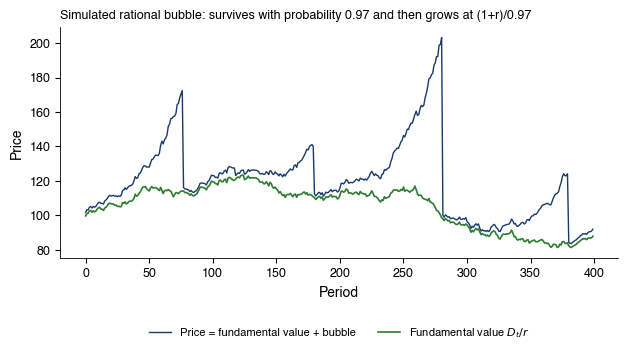

{'T': 400,
 'r': 0.01,
 'pi': 0.97,
 'growth': 0.04123711340206193,
 'life': 33.33333333333331,
 'collapses': 4,
 'max_share': 0.5146255950235038,
 'max_mult': 2.0602652091809914}

In [6]:
def fig_rational_bubble():
    """Pret = valoare fundamentala (dividende mers aleator, r = 1% pe perioada) + bula rationala care se prabuseste:
    supravietuieste cu probabilitatea pi = 0.97 si atunci creste cu (1+r)/pi; altfel reporneste de la o valoare mica."""
    rng = np.random.default_rng(48)
    T, r, pi, b0 = 400, 0.01, 0.97, 2.0
    D = 1 + np.cumsum(0.01 * rng.standard_normal(T))
    F = D / r                                           # E_t sum D_{t+i}/(1+r)^i cu dividende mers aleator
    Bb = np.empty(T)
    Bb[0] = b0
    alive = rng.random(T) < pi
    u = np.exp(rng.normal(-0.0005, 0.03, T))            # E[u] = 1
    for t in range(1, T):
        Bb[t] = (1 + r) / pi * Bb[t - 1] * u[t] if alive[t] else b0
    Pp = F + Bb
    collapses = int(sum(1 for t in range(1, T) if not alive[t] and Bb[t - 1] > 25))   # prabusiri vizibile (bula > 25)
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(Pp, color=MainBlue, lw=1.0, label='Price = fundamental value + bubble')
    ax.plot(F, color=Forest, lw=1.2, label='Fundamental value $D_t / r$')
    ax.set_xlabel('Period')
    ax.set_ylabel('Price')
    ax.set_title('Simulated rational bubble: survives with probability 0.97 and then grows at (1+r)/0.97',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.25)
    save_fig('ch17_rational_bubble')
    return dict(T=T, r=r, pi=pi, growth=(1 + r) / pi - 1, life=1 / (1 - pi), collapses=collapses,
                max_share=float(np.max(Bb / Pp)), max_mult=float(np.max(Pp / F)))


fig_rational_bubble()

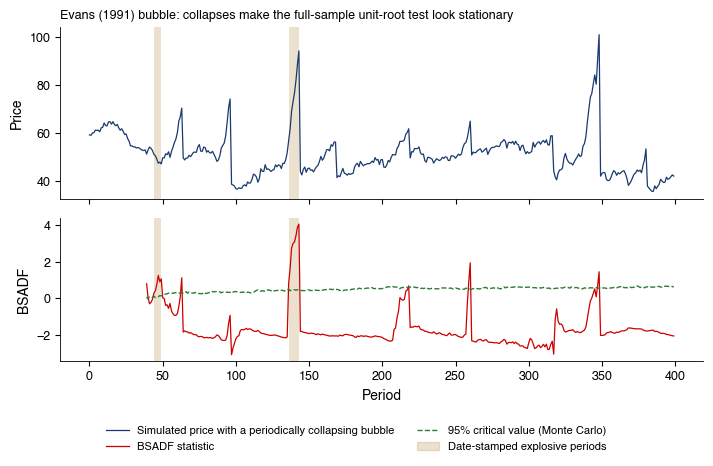

{'adf': -5.163761839211033,
 'sadf': 1.2587925634185306,
 'gsadf': 4.075071033632057,
 'cv_adf': -0.09479531243526572,
 'cv_sadf': 1.4589824017240867,
 'cv_gsadf': 2.211235749673446,
 'n_episodes': 2,
 'w0': 39,
 'T': 400}

In [7]:
def fig_evans():
    """Bula Evans (1991) care se prabuseste periodic: ADF pe toata selectia vs GSADF / BSADF."""
    T = 400
    B = evans_bubble(T=T, seed=11)
    rng = np.random.default_rng(5)
    D = 1 + np.cumsum(0.02 * rng.standard_normal(T))
    Pp = np.abs(D) / 0.02 + 20 * B
    y = np.log(Pp)
    res = psy(y)
    cv = psy_cv(res['n'], res['w0'], R_MC, SEED)
    L = int(np.ceil(np.log(res['n'])))
    ep = episodes(res['bsadf'], cv['bsadf95'], np.arange(1, T), L)
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(Pp, color=MainBlue, lw=0.9, label='Simulated price with a periodically collapsing bubble')
    axes[0].set_ylabel('Price')
    axes[1].plot(np.arange(1, T), res['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(np.arange(1, T), cv['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    for s, e, _ in ep:
        for ax in axes:
            ax.axvspan(s, e if e is not None else T, color=Amber, alpha=0.25, lw=0)
    axes[1].set_xlabel('Period')
    axes[1].set_ylabel('BSADF')
    axes[0].set_title('Evans (1991) bubble: collapses make the full-sample unit-root test look stationary',
                      fontsize=9, loc='left')
    fig.tight_layout()
    axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Date-stamped explosive periods')
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_evans')
    return dict(adf=res['adf'], sadf=res['sadf'], gsadf=res['gsadf'], cv_adf=cv['adf']['95'],
                cv_sadf=cv['sadf']['95'], cv_gsadf=cv['gsadf']['95'], n_episodes=len(ep), w0=res['w0'], T=T)


fig_evans()

## 2. Nine run-ups and crashes

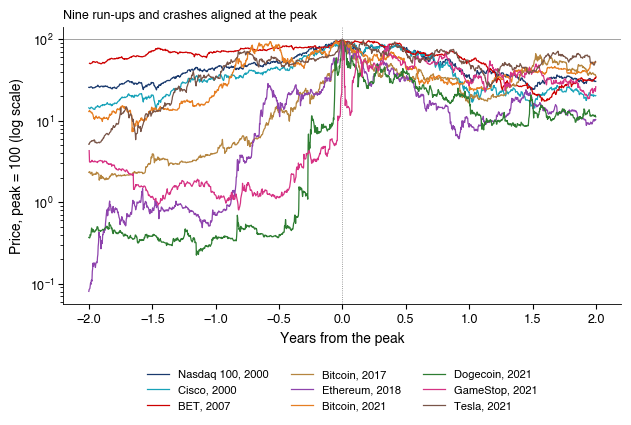

,key,label,peak,peak_price,runup2y,trough,maxdd,days_to_trough,recovered,years_to_recover
0,ndx,"Nasdaq 100, 2000",2000-03-27,4704.730000,2.882944,2002-10-07,-0.828972,924,2015-11-03,15.603012
1,csco,"Cisco, 2000",2000-03-27,51.336300,5.924331,2002-10-08,-0.892585,925,2021-08-24,21.409993
2,bet,"BET, 2007",2007-07-24,10813.590000,0.965568,2009-02-25,-0.825484,582,2021-03-16,13.645448
3,btc,"Bitcoin, 2017",2017-12-16,19497.400391,41.857647,2018-12-15,-0.833990,364,2020-11-30,2.956879
4,eth,"Ethereum, 2018",2018-01-13,1396.420044,1240.041595,2018-12-14,-0.939625,335,2021-02-02,3.055441
5,btc,"Bitcoin, 2021",2021-11-08,67566.830088,6.673793,2022-11-21,-0.766346,378,2024-03-04,2.318960
6,doge,"Dogecoin, 2021",2021-05-07,0.684777,268.973250,2022-06-18,-0.922585,407,None,NaN
7,gme,"GameStop, 2021",2021-01-27,86.877500,22.180933,2024-04-22,-0.884780,1181,None,NaN
8,tsla,"Tesla, 2021",2021-11-04,409.970000,18.370461,2023-01-03,-0.736322,425,2024-12-11,3.101985


In [8]:
EPISODES = [('ndx', 'Nasdaq 100, 2000', ('1999-01-01', '2000-12-31')), ('csco', 'Cisco, 2000', ('1999-01-01', '2000-12-31')), ('bet', 'BET, 2007', ('2006-01-01', '2008-06-30')), ('btc', 'Bitcoin, 2017', ('2017-06-01', '2018-03-31')), ('eth', 'Ethereum, 2018', ('2017-06-01', '2018-06-30')), ('btc', 'Bitcoin, 2021', ('2021-06-01', '2022-03-31')), ('doge', 'Dogecoin, 2021', ('2021-01-01', '2021-12-31')), ('gme', 'GameStop, 2021', ('2021-01-01', '2021-06-30')), ('tsla', 'Tesla, 2021', ('2021-06-01', '2022-06-30'))]


def episode_table():
    """Varf, crestere pe 2 ani inainte de varf, scadere maxima dupa varf, minim si revenire."""
    rows = []
    for k, lab, (a, b) in EPISODES:
        p = price(k, 'D')
        pk = p.loc[a:b].idxmax()
        pre = p.loc[:pk]
        start = pre.index[pre.index.searchsorted(pk - pd.DateOffset(years=2))]
        post = p.loc[pk:]
        dd = post / post.iloc[0] - 1
        tr = dd.loc[:pk + pd.DateOffset(years=4)].idxmin()
        rec = post.loc[tr:][post.loc[tr:] >= post.iloc[0]]
        rows.append(dict(key=k, label=lab, peak=d2s(pk), peak_price=float(p.loc[pk]), runup2y=float(p.loc[pk] / p.loc[start] - 1),
                         trough=d2s(tr), maxdd=float(dd.loc[tr]), days_to_trough=int((tr - pk).days),
                         recovered=d2s(rec.index[0]) if len(rec) else None,
                         years_to_recover=float((rec.index[0] - pk).days / 365.25) if len(rec) else None))
    return rows


def fig_episodes(tab):
    """Episoade aliniate la varf: pret normalizat = 100 la varf, +/- 2 ani calendaristici."""
    cols = [MainBlue, Teal, IDAred, Amber, Purple, Orange, Forest, Magenta, Brown]
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    for (k, lab, _), row, c in zip(EPISODES, tab, cols):
        p = price(k, 'D')
        pk = pd.Timestamp(row['peak'])
        w = p.loc[pk - pd.DateOffset(years=2):pk + pd.DateOffset(years=2)]
        x = (w.index - pk).days / 365.25
        ax.plot(x, 100 * w.values / p.loc[pk], color=c, lw=0.9, label=lab)
    ax.set_yscale('log')
    ax.axvline(0, color=Gray, lw=0.6, ls=':')
    ax.axhline(100, color=Gray, lw=0.5)
    ax.set_xlabel('Years from the peak')
    ax.set_ylabel('Price, peak = 100 (log scale)')
    ax.set_title('Nine run-ups and crashes aligned at the peak', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch17_episodes')


tab = episode_table()
fig_episodes(tab)
pd.DataFrame(tab)

## 3. Bubbles for Fama: 49 US industries

- Run-up: two-year return above a threshold, raw and net of the market; crash: 40% drawdown within the next two years.

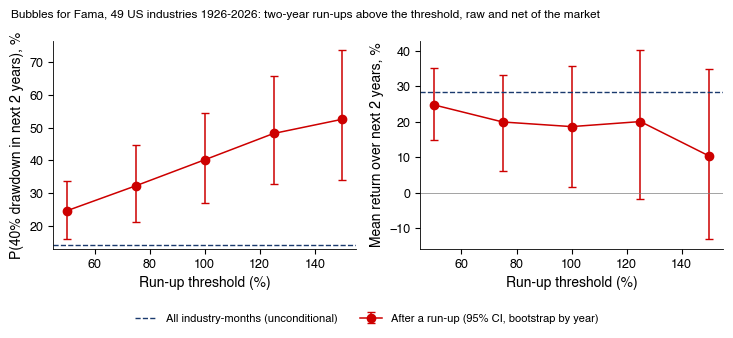

,thr,n,n_ind,crash,crash_ci,ret2,ret2_ci,first,last
0,0.50,390,49,0.246154,"[0.15872609913530628, 0.3360444802795135]",0.247426,"[0.14853239453725858, 0.3517716617521164]",1928-07-31,2024-06-30
1,0.75,211,48,0.322275,"[0.21051883971291865, 0.44829345531315967]",0.199266,"[0.06090398685875653, 0.33089906605693875]",1928-07-31,2024-06-30
2,1.00,127,42,0.401575,"[0.2710041612661164, 0.5441510695187164]",0.186258,"[0.015334080863432456, 0.35770469214146466]",1928-07-31,2024-02-29
3,1.25,83,36,0.481928,"[0.3272541743970315, 0.6562578914141414]",0.200453,"[-0.01861119850714577, 0.4018229181678273]",1928-07-31,2022-03-31
4,1.50,59,29,0.525424,"[0.3387034739454094, 0.7368734335839597]",0.103392,"[-0.1309706570769726, 0.3479410549347357]",1928-07-31,2022-08-31


In [9]:
def gsy_events(thr, H=24, crash=0.40):
    """Cresteri de peste thr in 2 ani (brut si peste piata); prabusire = scadere de 40% in urmatorii 2 ani."""
    ind, mkt = industries()
    ind = ind.loc[:, ind.notna().mean() > 0]
    Pm = (1 + mkt.reindex(ind.index)).cumprod()
    runm = Pm / Pm.shift(H) - 1
    rows = []
    for c in ind.columns:
        r = ind[c]
        valid = r.notna()
        p = (1 + r.fillna(0)).cumprod()
        run = p / p.shift(H) - 1
        cond = (run > thr) & ((run - runm) > thr) & valid & valid.shift(H, fill_value=False)
        last = None
        for i in np.where(cond.values)[0]:
            if (last is not None and i - last < H) or i + H >= len(p):
                continue
            fut = p.iloc[i:i + H + 1].values
            rows.append(dict(ind=c, date=p.index[i], run=float(run.iloc[i]),
                             mdd=float((fut / np.maximum.accumulate(fut) - 1).min()), ret2=float(fut[-1] / fut[0] - 1)))
            last = i
    d = pd.DataFrame(rows)
    d['crash'] = d['mdd'] <= -crash
    return d


def gsy_unconditional(H=24, crash=0.40):
    """Probabilitatea neconditionata a unei scaderi de 40% in 2 ani (toate lunile-industrie)."""
    ind, _ = industries()
    ind = ind.loc[:, ind.notna().mean() > 0]
    hits, n, rets = 0, 0, []
    for c in ind.columns:
        r = ind[c]
        p = (1 + r.fillna(0)).cumprod().values
        v = r.notna().values
        for i in range(len(p) - H):
            if not v[i]:
                continue
            fut = p[i:i + H + 1]
            hits += (fut / np.maximum.accumulate(fut) - 1).min() <= -crash
            rets.append(fut[-1] / fut[0] - 1)
            n += 1
    return hits / n, float(np.mean(rets)), n


def cluster_boot(d, col, B=2000, seed=SEED):
    """Interval bootstrap de 95% cu reesantionare pe ani calendaristici (episoadele din acelasi an sunt corelate)."""
    rng = np.random.default_rng(seed)
    g = {y: grp[col].values for y, grp in d.groupby(d['date'].dt.year)}
    keys = list(g)
    stats = []
    for _ in range(B):
        pick = rng.choice(len(keys), len(keys), replace=True)
        v = np.concatenate([g[keys[j]] for j in pick])
        stats.append(v.mean())
    return [float(np.quantile(stats, 0.025)), float(np.quantile(stats, 0.975))]


def fig_gsy():
    thrs = [0.5, 0.75, 1.0, 1.25, 1.5]
    pu, ru, nu = gsy_unconditional()
    out = dict(uncond_crash=pu, uncond_ret2=ru, n_months=nu, rows=[])
    for th in thrs:
        d = gsy_events(th)
        out['rows'].append(dict(thr=th, n=int(len(d)), n_ind=int(d['ind'].nunique()), crash=float(d['crash'].mean()),
                                crash_ci=cluster_boot(d, 'crash'), ret2=float(d['ret2'].mean()),
                                ret2_ci=cluster_boot(d, 'ret2'), first=d2s(d['date'].min()), last=d2s(d['date'].max())))
    R = pd.DataFrame(out['rows'])
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))
    x = 100 * R['thr']
    lo = np.array([c[0] for c in R['crash_ci']])
    hi = np.array([c[1] for c in R['crash_ci']])
    axes[0].errorbar(x, 100 * R['crash'], yerr=[100 * (R['crash'] - lo), 100 * (hi - R['crash'])], fmt='o-',
                     color=IDAred, capsize=3, label='After a run-up (95% CI, bootstrap by year)')
    axes[0].axhline(100 * pu, color=MainBlue, ls='--', lw=1.0, label='All industry-months (unconditional)')
    axes[0].set_xlabel('Run-up threshold (%)')
    axes[0].set_ylabel('P(40% drawdown in next 2 years), %')
    lo = np.array([c[0] for c in R['ret2_ci']])
    hi = np.array([c[1] for c in R['ret2_ci']])
    axes[1].errorbar(x, 100 * R['ret2'], yerr=[100 * (R['ret2'] - lo), 100 * (hi - R['ret2'])], fmt='o-',
                     color=IDAred, capsize=3)
    axes[1].axhline(100 * ru, color=MainBlue, ls='--', lw=1.0)
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xlabel('Run-up threshold (%)')
    axes[1].set_ylabel('Mean return over next 2 years, %')
    fig.suptitle('Bubbles for Fama, 49 US industries 1926-2026: two-year run-ups above the threshold, raw and net of the market',
                 fontsize=8.5, x=0.02, ha='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_gsy')
    return out


res = fig_gsy()
pd.DataFrame(res['rows'])

## 4. Windows and null distributions

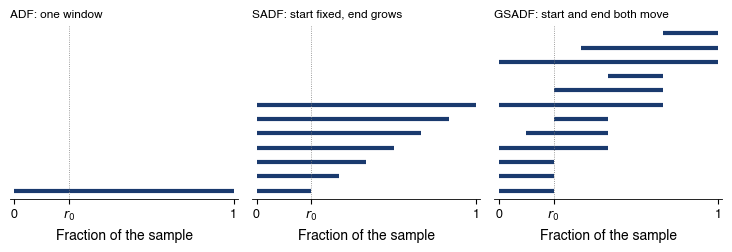

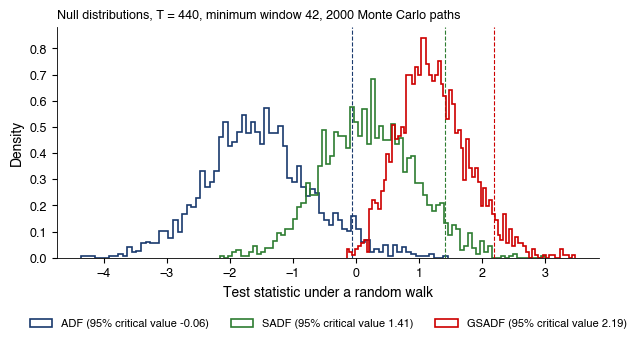

{'adf': {'90': -0.44019069100256664,
  '95': -0.06104151866652127,
  '99': 0.6525273541791642},
 'sadf': {'90': 1.1674363323454702,
  '95': 1.4103426039958415,
  '99': 1.975277982512124},
 'gsadf': {'90': 1.9614984190261007,
  '95': 2.187861617328365,
  '99': 2.64984740456162}}

In [10]:
def fig_windows():
    """Schema ferestrelor: ADF (toata selectia), SADF (inceput fix, sfarsit variabil), GSADF (ambele variabile)."""
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.6), sharey=True)
    specs = [('ADF: one window', [(0, 1)]),
             ('SADF: start fixed, end grows', [(0, e) for e in np.linspace(0.25, 1, 7)]),
             ('GSADF: start and end both move', [(s, e) for e in np.linspace(0.25, 1, 4) for s in np.linspace(0, e - 0.25, 3)])]
    for ax, (title, wins) in zip(axes, specs):
        for i, (s, e) in enumerate(wins):
            ax.plot([s, e], [i, i], color=MainBlue if 'ADF:' in title else (Forest if 'SADF:' in title else IDAred), lw=3,
                    solid_capstyle='butt')
        ax.axvline(0.25, color=Gray, lw=0.6, ls=':')
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlim(-0.02, 1.02)
        ax.set_xticks([0, 0.25, 1])
        ax.set_xticklabels(['0', '$r_0$', '1'])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.set_xlabel('Fraction of the sample')
    fig.tight_layout()
    save_fig('ch17_windows')


def fig_null(cv, T):
    """Distributiile sub ipoteza nula (mers aleator) ale ADF, SADF si GSADF, cu valorile critice de 95%."""
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    for k, c, lab in [('adf', MainBlue, 'ADF'), ('sadf', Forest, 'SADF'), ('gsadf', IDAred, 'GSADF')]:
        v = cv['null'][k]
        ax.hist(v, bins=80, density=True, histtype='step', color=c, lw=1.2, label=f'{lab} (95% critical value {cv[k]["95"]:.2f})')
        ax.axvline(cv[k]['95'], color=c, ls='--', lw=0.8)
    ax.set_xlabel('Test statistic under a random walk')
    ax.set_ylabel('Density')
    ax.set_title(f'Null distributions, T = {T}, minimum window {cv["w0"]}, {cv["R"]} Monte Carlo paths', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.22)
    save_fig('ch17_null')


fig_windows()
y_ndx = np.log(price('ndx', 'M'))
o_ndx = run_psy(y_ndx)
fig_null(o_ndx['cv'], o_ndx['res']['n'])
{k: o_ndx['cv'][k] for k in ['adf', 'sadf', 'gsadf']}

## 5. S&P 500 price-dividend ratio, 1871–2024

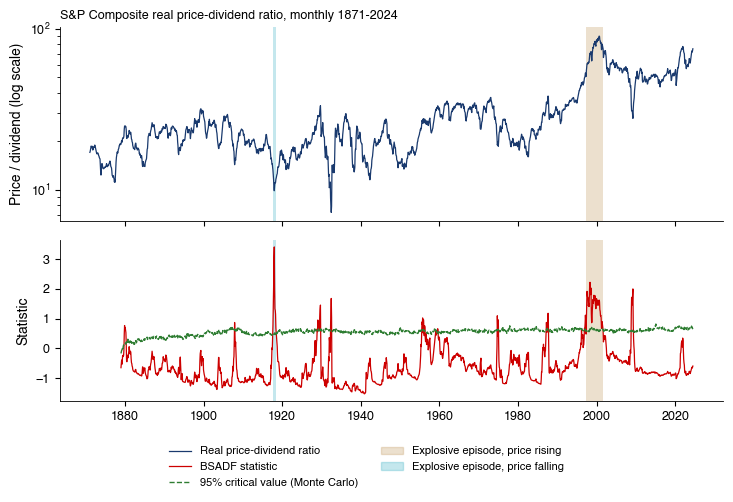

[{'start': '1917-08-31',
  'end': '1918-05-31',
  'n': 10,
  'change': -0.11865328253223906},
 {'start': '1997-05-31',
  'end': '2001-07-31',
  'n': 51,
  'change': 0.3923775787946038}]

In [11]:
sh = shiller()
y_pd = np.log(sh['PD'])
o_pd = run_psy(y_pd, R=1000)
fig_psy(y_pd, o_pd, 'ch17_sp_pd', 'S&P Composite real price-dividend ratio, monthly 1871-2024', 'Price / dividend (log scale)', level=sh['PD'], level_label='Real price-dividend ratio')
summarise(o_pd, y_pd)['episodes']

## 6. Nasdaq 100, Bitcoin, BET and GameStop

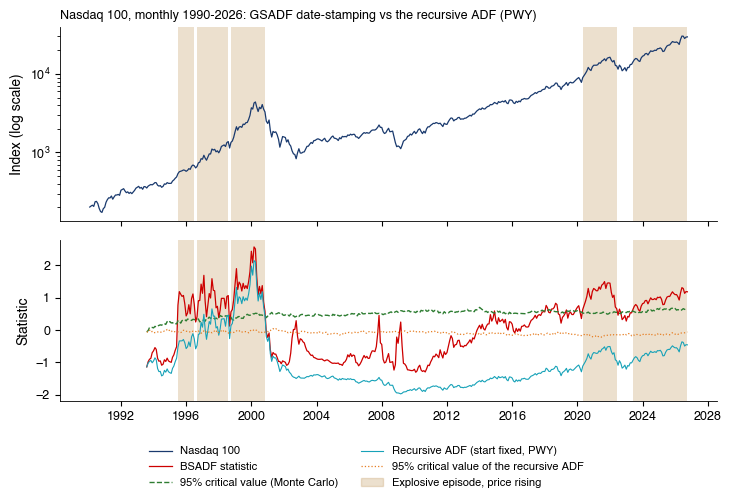

,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,1995-06-30,1996-06-30,1996-12-09,528,0.258852,0.592179,-0.084890,-162.0
1,1996-08-31,1998-07-31,1999-01-29,881,1.075531,2.205675,-0.112134,-182.0
2,1998-09-30,2000-10-31,2000-03-27,544,1.439501,2.496693,-0.760464,218.0
3,2020-04-30,2022-05-31,2021-11-19,568,0.404598,0.841378,-0.355631,193.0
4,2023-05-31,None,2026-06-02,1098,1.079696,1.151004,-0.113119,NaN


In [12]:
fig_psy(y_ndx, o_ndx, 'ch17_ndx', 'Nasdaq 100, monthly 1990-2026: GSADF date-stamping vs the recursive ADF (PWY)', 'Index (log scale)', pwy=True, level_label='Nasdaq 100')
pd.DataFrame(real_time(o_ndx, price('ndx', 'D')))

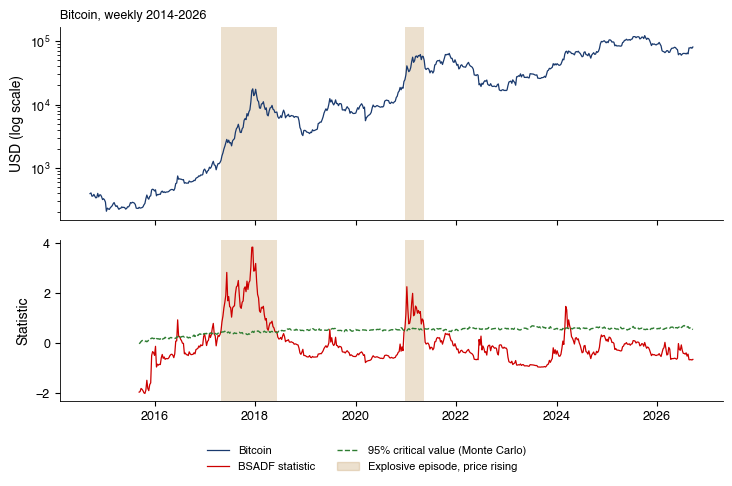

3.848666319133873 {'90': 2.011965367670432, '95': 2.2705159532859884, '99': 2.6910831812657494} 2.8225047174576106


,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,2017-04-28,2018-06-08,2017-12-16,232,4.791900,13.810252,-0.833990,174
1,2020-12-25,2021-05-14,2021-11-08,318,1.022338,1.739404,-0.766346,-178


In [13]:
y_btc = np.log(price('btc', 'W'))
o_btc = run_psy(y_btc, wild=True)
fig_psy(y_btc, o_btc, 'ch17_btc', 'Bitcoin, weekly 2014-2026', 'USD (log scale)', level_label='Bitcoin')
s = summarise(o_btc, y_btc)
print(s['gsadf'], s['cv_gsadf'], s['cv_gsadf_wild'])
pd.DataFrame(real_time(o_btc, price('btc', 'D')))

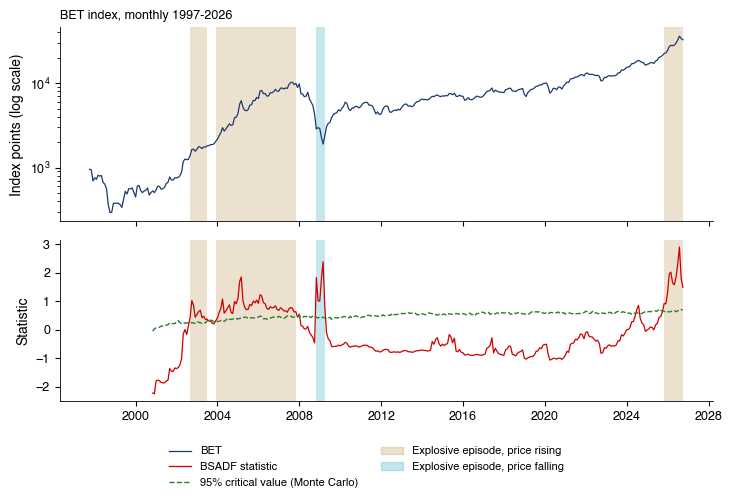

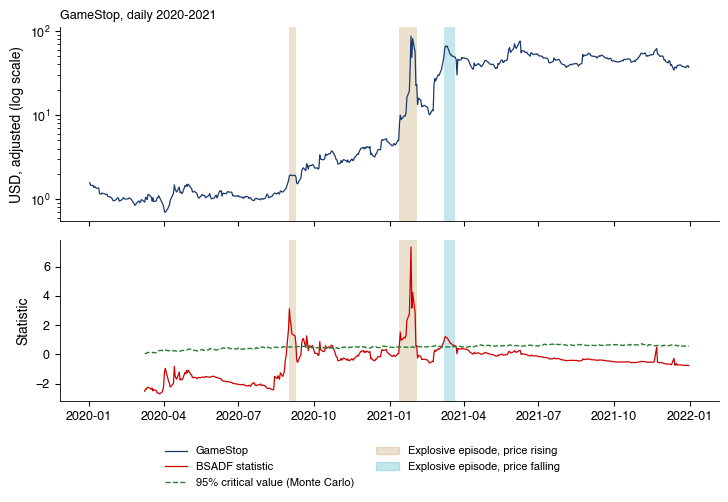

,start,end,peak,lead_days,change,gain_to_peak,dd_after,signal_end_after_peak_days
0,2002-08-31,2003-06-30,2003-12-19,475,0.300800,0.558780,0.000000,-172.0
1,2003-11-30,2007-10-31,2007-07-24,1332,3.868541,4.291027,-0.825484,99.0
2,2008-10-31,2009-03-31,2009-09-23,327,-0.174047,0.550575,-0.072155,-176.0
3,2025-10-31,None,2026-08-19,292,0.454817,0.620445,-0.131387,NaN


In [14]:
y_bet = np.log(price('bet', 'M'))
o_bet = run_psy(y_bet)
fig_psy(y_bet, o_bet, 'ch17_bet', 'BET index, monthly 1997-2026', 'Index points (log scale)', level_label='BET')
y_gme = np.log(price('gme', 'D', '2020-01-01', '2021-12-31'))
o_gme = run_psy(y_gme)
fig_psy(y_gme, o_gme, 'ch17_gme', 'GameStop, daily 2020-2021', 'USD, adjusted (log scale)', level_label='GameStop')
pd.DataFrame(real_time(o_bet, price('bet', 'D')))

## 7. Real time vs hindsight: first signal and peak

In [15]:
pd.DataFrame({
    'ndx': signal_vs_peak(o_ndx, price('ndx', 'D'), ('1999-01-01', '2000-12-31'), 93),
    'bet': signal_vs_peak(o_bet, price('bet', 'D'), ('2006-01-01', '2008-06-30'), 93),
    'btc17': signal_vs_peak(o_btc, price('btc', 'D'), ('2017-06-01', '2018-03-31'), 28),
    'btc21': signal_vs_peak(o_btc, price('btc', 'D'), ('2021-01-01', '2021-06-30'), 28),
    'gme': signal_vs_peak(o_gme, price('gme', 'D'), ('2021-01-01', '2021-06-30'), 10, dd_years=1)}).T

,first,peak,lead_days,lead_months,gain,dd_after,signal_end
ndx,1995-06-30,2000-03-27,1732,56.898817,7.744364,-0.760464,2000-10-31
bet,2003-11-30,2007-07-24,1332,43.758213,4.291027,-0.825484,2007-10-31
btc17,2017-04-28,2017-12-16,232,7.621551,13.810252,-0.83399,2018-06-08
btc21,2020-12-25,2021-04-13,109,3.580815,1.57466,-0.751395,2021-05-14
gme,2021-01-13,2021-01-27,14,0.459921,10.067197,-0.883198,2021-02-03


## 8. LPPLS: Bitcoin 2017 and the instability of the critical time

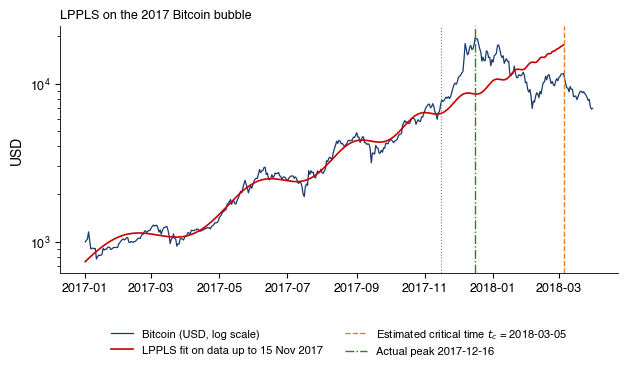

{'tc': 2018.1727535404762, 'm': 0.9142628663606351, 'w': 16.87835646414336, 'A': 9.774183869368638, 'B': -2.7929552606610293, 'C1': 0.028842173496802546, 'C2': 0.20830119396516725, 'C': 0.21028851223814837, 'ssr': 2.554644474527237, 'rmse': 0.08948904898813104, 'damping': 0.7194313464169163, 'osc': 3.64338085370488, 't1': '2017-01-01', 't2': '2017-11-15', 'tc_date': '2018-03-05', 'peak': '2017-12-16', 'qualified': False}


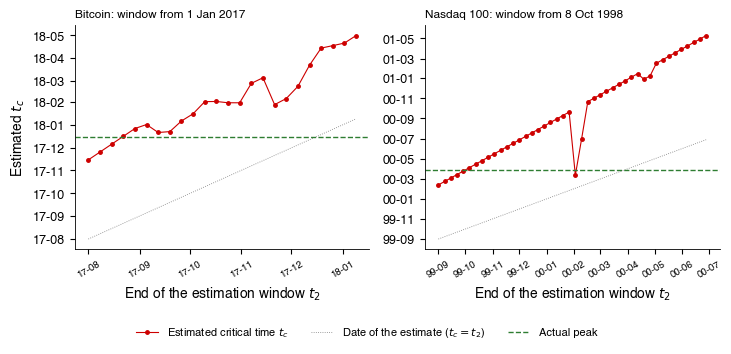

{'btc': {'peak': '2017-12-16',
  'n': 24,
  'n_before': 20,
  'mae_days': 36.9,
  'med_err_days': 36.0,
  'min_tc': '2017-11-15',
  'max_tc': '2018-03-21',
  'share_within_30': 0.45,
  'share_qualified': 0.0},
 'ndx': {'peak': '2000-03-27',
  'n': 44,
  'n_before': 30,
  'mae_days': 106.5,
  'med_err_days': 93.5,
  'min_tc': '2000-02-11',
  'max_tc': '2000-12-12',
  'share_within_30': 0.23333333333333334,
  'share_qualified': 0.0}}

In [16]:
def fig_lppls_btc2017():
    """LPPLS ajustat pe Bitcoin 2017-01-01 .. 2017-11-15 si traiectoria observata pana in martie 2018."""
    p = price('btc', 'D')
    t1, t2 = '2017-01-01', '2017-11-15'
    w = p.loc[t1:t2]
    f = lppls_fit(yrs(w.index), np.log(w.values), tc_rng=(0.0, 0.5))
    full = p.loc[t1:'2018-03-31']
    tt = yrs(full.index)
    mask = tt < f['tc']
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.plot(full.index, full.values, color=MainBlue, lw=0.9, label='Bitcoin (USD, log scale)')
    ax.plot(full.index[mask], np.exp(lppls_path(f, tt[mask])), color=IDAred, lw=1.2, label='LPPLS fit on data up to 15 Nov 2017')
    ax.axvline(pd.Timestamp(t2), color=Gray, ls=':', lw=0.8)
    ax.axvline(todate(f['tc']), color=Orange, ls='--', lw=1.0, label=f"Estimated critical time $t_c$ = {todate(f['tc']).date()}")
    pk = p.loc['2017'].idxmax()
    ax.axvline(pk, color=Forest, ls='-.', lw=1.0, label=f'Actual peak {pk.date()}')
    ax.set_yscale('log')
    ax.set_ylabel('USD')
    ax.set_title('LPPLS on the 2017 Bitcoin bubble', fontsize=9, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    save_fig('ch17_lppls_btc2017')
    f.update(tc_date=d2s(todate(f['tc'])), peak=d2s(pk), t1=t1, t2=t2, qualified=lppls_qualified(f))
    return f


def tc_path(key, t1, t2_from, t2_to, step_days=7):
    """tc estimat pe ferestre [t1, t2] cu t2 mobil (la fiecare step_days zile)."""
    p = price(key, 'D')
    rows = []
    for t2 in pd.date_range(t2_from, t2_to, freq=f'{step_days}D'):
        w = p.loc[t1:t2]
        f = lppls_fit(yrs(w.index), np.log(w.values), tc_rng=(0.0, 0.5))
        rows.append(dict(t2=w.index[-1], tc=todate(f['tc']), m=f['m'], w=f['w'], q=lppls_qualified(f)))
    return pd.DataFrame(rows)


def fig_tc_instability():
    cases = [('btc', 'Bitcoin: window from 1 Jan 2017', '2017-01-01', '2017-08-01', '2018-01-15', ('2017-06-01', '2018-03-31')),
             ('ndx', 'Nasdaq 100: window from 8 Oct 1998', '1998-10-08', '1999-09-01', '2000-06-30', ('1999-06-01', '2000-12-31'))]
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
    out = {}
    for ax, (k, title, t1, a, b, (pa, pb)) in zip(axes, cases):
        d = tc_path(k, t1, a, b)
        pk = price(k, 'D').loc[pa:pb].idxmax()
        ax.plot(d['t2'], d['tc'], 'o-', color=IDAred, ms=2.5, lw=0.8, label='Estimated critical time $t_c$')
        ax.plot(d['t2'], d['t2'], color=Gray, lw=0.6, ls=':', label='Date of the estimate ($t_c = t_2$)')
        ax.axhline(pk, color=Forest, ls='--', lw=1.0, label='Actual peak')
        ax.set_title(title, fontsize=8.5, loc='left')
        ax.set_xlabel('End of the estimation window $t_2$')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        ax.yaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        err = (d['tc'] - pk).dt.days
        before = d['t2'] < pk
        out[k] = dict(peak=d2s(pk), n=int(len(d)), n_before=int(before.sum()),
                      mae_days=float(err[before].abs().mean()), med_err_days=float(err[before].median()),
                      min_tc=d2s(d.loc[before, 'tc'].min()), max_tc=d2s(d.loc[before, 'tc'].max()),
                      share_within_30=float((err[before].abs() <= 30).mean()), share_qualified=float(d.loc[before, 'q'].mean()))
    axes[0].set_ylabel('Estimated $t_c$')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig('ch17_tc_instability')
    return out


print(fig_lppls_btc2017())
fig_tc_instability()

## 9. LPPLS confidence indicator

- With `RECOMPUTE = False` the indicators are read from the chapter's published files; `True` recomputes them (several minutes).

In [17]:
CI_WINDOWS = [90, 150, 210, 270, 330, 390, 450, 510, 570, 630, 690]


def confidence_series(key, start, t2_from, step=14):
    """Indicatorul de incredere LPPLS la fiecare step observatii, dupa t2_from."""
    p = price(key, 'D', start)
    t, y = yrs(p.index), np.log(p.values)
    i0 = int(p.index.searchsorted(pd.Timestamp(t2_from)))
    idx = np.arange(max(i0, max(CI_WINDOWS)), len(p), step)
    ci = [lppls_confidence(t, y, i, CI_WINDOWS) for i in idx]
    return pd.Series(ci, index=p.index[idx], name='ci')


def ci_evaluation(ci, p, horizon=90, fall=0.20):
    """Semnal (indicator > 0) vs o scadere de cel putin 20% sub pretul curent in urmatoarele 90 de zile."""
    rows = []
    for d, v in ci.items():
        fut = p.loc[d:d + pd.Timedelta(days=horizon)]
        rows.append(dict(date=d, ci=v, hit=bool(fut.min() / fut.iloc[0] - 1 <= -fall)))
    r = pd.DataFrame(rows)
    on, off = r[r.ci > 0], r[r.ci == 0]
    return dict(n=int(len(r)), n_on=int(len(on)), p_on=float(on.hit.mean()) if len(on) else None,
                p_off=float(off.hit.mean()), base=float(r.hit.mean()), horizon=horizon, fall=fall)


def fig_lppls_ci(ci_btc):
    p = price('btc', 'D', '2015-01-01')
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), sharex=True, gridspec_kw=dict(height_ratios=[1.3, 1]))
    axes[0].plot(p.index, p.values, color=MainBlue, lw=0.8, label='Bitcoin (USD, log scale)')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('USD')
    axes[1].bar(ci_btc.index, ci_btc.values, width=12, color=IDAred, label='LPPLS confidence indicator (share of qualified windows)')
    axes[1].set_ylabel('Share')
    axes[1].set_ylim(0, 1)
    axes[0].set_title('Bitcoin: real-time LPPLS confidence indicator, 11 windows of 90-690 days, every 2 weeks',
                      fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_lppls_ci')

In [18]:
def get_ci(key, start, t2_from, fname):
    """LPPLS confidence indicator: recomputed (RECOMPUTE = True, several minutes) or read from the published file."""
    if RECOMPUTE:
        return confidence_series(key, start, t2_from)
    path = os.path.join(HERE, fname)
    return pd.read_csv(path if os.path.exists(path) else QL_RAW + fname, index_col=0, parse_dates=True)['ci']

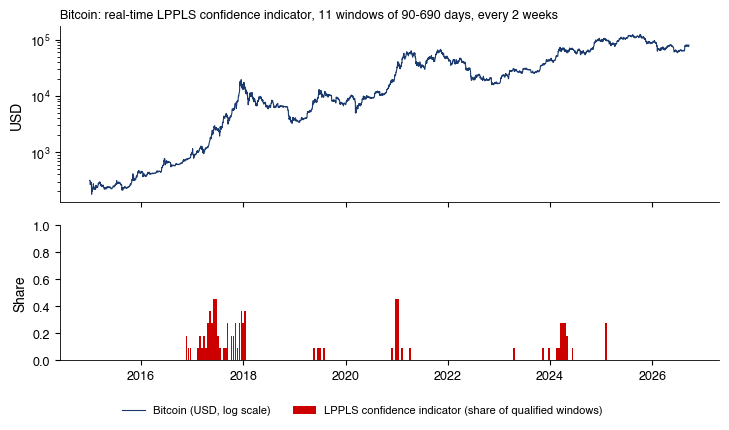

{'n': 257, 'n_on': 46, 'p_on': 0.3695652173913043, 'p_off': 0.38388625592417064, 'base': 0.38132295719844356, 'horizon': 90, 'fall': 0.2}
{'n': 534, 'n_on': 143, 'p_on': 0.03496503496503497, 'p_off': 0.08439897698209718, 'base': 0.07116104868913857, 'horizon': 90, 'fall': 0.2}


In [19]:
ci_btc = get_ci('btc', '2015-01-01', '2016-06-01', 'ch17_lppls_ci_btc.csv')
ci_ndx = get_ci('ndx', '1994-01-01', '1997-01-01', 'ch17_lppls_ci_ndx.csv')
fig_lppls_ci(ci_btc)
print(ci_evaluation(ci_btc, price('btc', 'D')))
print(ci_evaluation(ci_ndx, price('ndx', 'D')))

## 10. Markov-switching regimes

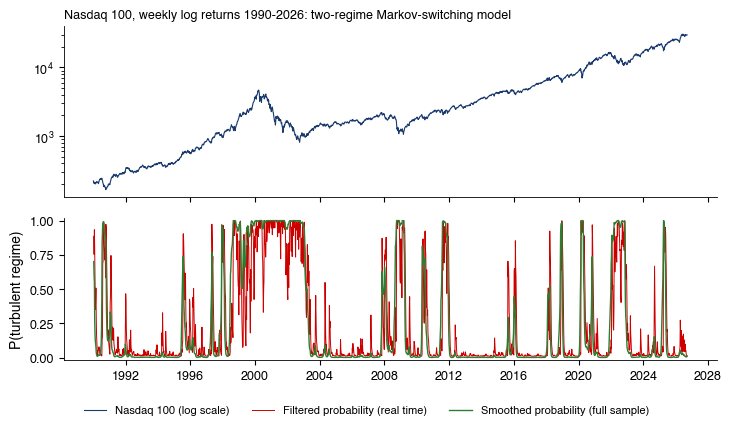

{'n': 1915,
 'start': '1990-01-12',
 'end': '2026-09-18',
 'llf': -4773.916664445049,
 'aic': 9559.833328890098,
 'bic': 9593.178166299786,
 'calm': {'mu': 0.4327161728505748,
  'mu_se': 0.06492592406392435,
  'sd': 2.2956407442121987,
  'stay': 0.9867409753196468,
  'dur': 75.42032872763004,
  'share': 0.76482490338972},
 'turb': {'mu': -0.32125949738459,
  'mu_se': 0.269515940321778,
  'sd': 5.397152552669112,
  'stay': 0.9573677661067832,
  'dur': 23.45642976403143,
  'share': 0.2351750966102743}}

In [20]:
def ms_fit(key, start, freq='W', k=2):
    """Markov-switching: medie si dispersie diferite pe regim, randamente log saptamanale in %."""
    import statsmodels.api as sm
    p = price(key, freq, start)
    r = 100 * np.log(p).diff().dropna()
    res = sm.tsa.MarkovRegression(r, k_regimes=k, trend='c', switching_variance=True).fit(search_reps=20, disp=False)
    hi = int(np.argmax([res.params[f'sigma2[{j}]'] for j in range(k)]))
    return p, r, res, hi


def ms_summary(res, hi, r, k=2):
    par = res.params
    se = res.bse
    lo = 1 - hi if k == 2 else None
    P = np.asarray(res.regime_transition)[:, :, 0]         # P[i, j] = P(s_t = i | s_{t-1} = j)
    out = dict(n=int(len(r)), start=d2s(r.index[0]), end=d2s(r.index[-1]), llf=float(res.llf), aic=float(res.aic),
               bic=float(res.bic))
    for j, tag in [(lo, 'calm'), (hi, 'turb')]:
        out[tag] = dict(mu=float(par[f'const[{j}]']), mu_se=float(se[f'const[{j}]']),
                        sd=float(np.sqrt(par[f'sigma2[{j}]'])), stay=float(P[j, j]),
                        dur=float(res.expected_durations[j]), share=float(res.smoothed_marginal_probabilities[j].mean()))
    return out


def fig_ms(key, start, name, title):
    p, r, res, hi = ms_fit(key, start)
    fp = res.filtered_marginal_probabilities[hi]
    sp = res.smoothed_marginal_probabilities[hi]
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(p.index, p.values, color=MainBlue, lw=0.8, label=f'{LABELS[key]} (log scale)')
    axes[0].set_yscale('log')
    axes[1].plot(fp.index, fp.values, color=IDAred, lw=0.7, label='Filtered probability (real time)')
    axes[1].plot(sp.index, sp.values, color=Forest, lw=1.0, label='Smoothed probability (full sample)')
    axes[1].set_ylabel('P(turbulent regime)')
    axes[1].set_ylim(-0.02, 1.02)
    axes[0].set_title(title, fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig(name)
    out = ms_summary(res, hi, r)
    # probabilitatea filtrata la varfuri si la 3 luni dupa
    return out, fp, sp


ms_ndx, fp_ndx, sp_ndx = fig_ms('ndx', '1990-01-01', 'ch17_ms_ndx', 'Nasdaq 100, weekly log returns 1990-2026: two-regime Markov-switching model')
ms_ndx

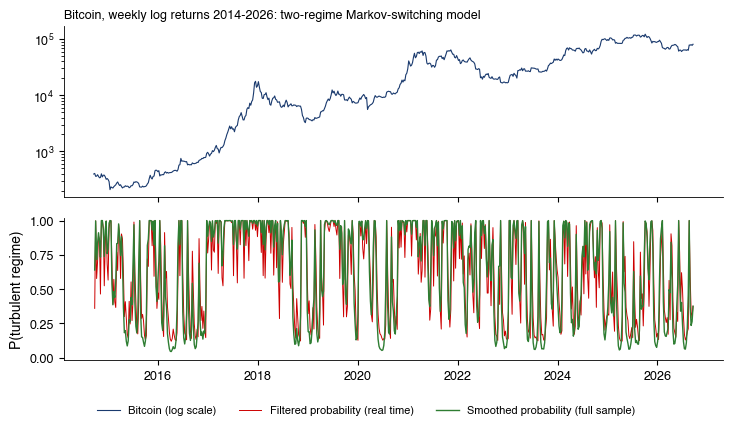

{'n': 626,
 'start': '2014-09-26',
 'end': '2026-09-18',
 'llf': -2205.839722960915,
 'aic': 4423.67944592183,
 'bic': 4450.315548148431,
 'calm': {'mu': 0.26235121971433667,
  'mu_se': 0.2795654880771109,
  'sd': 2.9258718545516307,
  'stay': 0.7356581865193369,
  'dur': 3.782980780954471,
  'share': 0.37645883625022974},
 'turb': {'mu': 1.204708868380811,
  'mu_se': 0.5789195154042145,
  'sd': 11.222504501532647,
  'stay': 0.8400644589942439,
  'dur': 6.252518944266488,
  'share': 0.6235411637497759}}

In [21]:
ms_btc, fp_btc, sp_btc = fig_ms('btc', '2014-09-17', 'ch17_ms_btc', 'Bitcoin, weekly log returns 2014-2026: two-regime Markov-switching model')
ms_btc

## 11. Crypto and AI

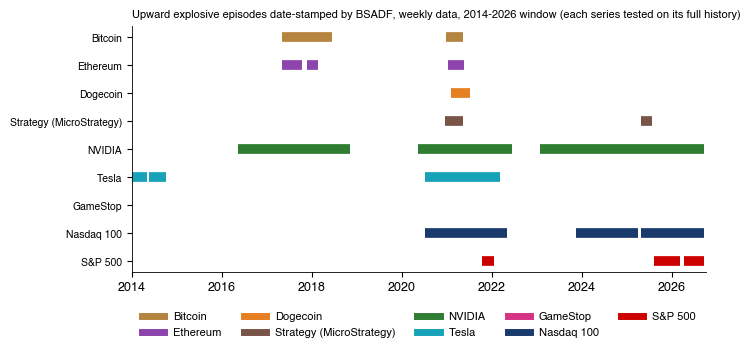

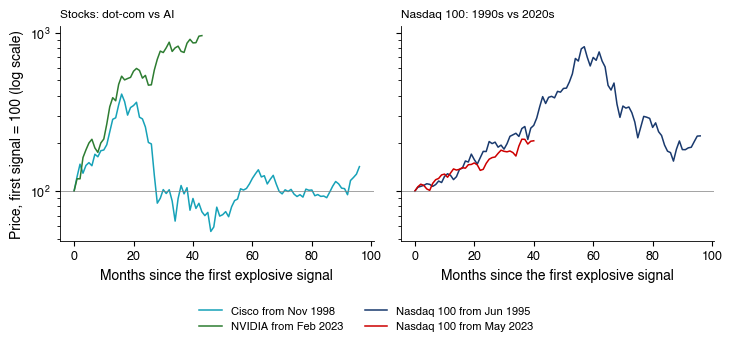

{'csco': {'start': '1998-11-30',
  'months': 96,
  'peak_mult': 4.102808147185645,
  'months_to_peak': 16,
  'last_mult': 1.4280582982280452},
 'nvda': {'start': '2023-02-28',
  'months': 43,
  'peak_mult': 9.60602629372564,
  'months_to_peak': 43,
  'last_mult': 9.60602629372564},
 'ndx95': {'start': '1995-06-30',
  'months': 96,
  'peak_mult': 8.173967622623271,
  'months_to_peak': 57,
  'last_mult': 2.233499804843596},
 'ndx23': {'start': '2023-05-31',
  'months': 40,
  'peak_mult': 2.128033436410648,
  'months_to_peak': 36,
  'last_mult': 2.0796957445855275}}

In [22]:
TIMELINE = ['btc', 'eth', 'doge', 'mstr', 'nvda', 'tsla', 'gme', 'ndx', 'sp500']


def fig_timeline():
    out = {}
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    cols = [Amber, Purple, Orange, Brown, Forest, Teal, Magenta, MainBlue, IDAred]
    for i, (k, c) in enumerate(zip(TIMELINE, cols)):
        y = np.log(price(k, 'W'))
        o = run_psy(y, R=1000)
        out[k] = summarise(o, y)
        for s, e, _ in o['ep']:
            e2 = e if e is not None else y.index[-1]
            if e2 < pd.Timestamp('2014-01-01') or _chg(y, s, e) <= 0:
                continue                                   # doar episoadele de crestere, 2014-2026
            ax.plot([max(s, pd.Timestamp('2014-01-01')), e2], [i, i], color=c, lw=7, solid_capstyle='butt')
        ax.plot([], [], color=c, lw=5, label=LABELS[k])
    ax.set_yticks(range(len(TIMELINE)))
    ax.set_yticklabels([LABELS[k] for k in TIMELINE], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlim(pd.Timestamp('2014-01-01'), pd.Timestamp('2026-10-01'))
    ax.set_title('Upward explosive episodes date-stamped by BSADF, weekly data, 2014-2026 window (each series tested on its full history)',
                 fontsize=8, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.12)
    save_fig('ch17_timeline')
    return out


def fig_ai_dotcom():
    """Cisco (dot-com) vs NVIDIA (AI) si Nasdaq 100 1995 vs 2023: pret = 100 la inceputul episodului exploziv (lunar)."""
    res = {}
    for k in ['csco', 'nvda', 'ndx']:
        y = np.log(price(k, 'M'))
        res[k] = (y, run_psy(y))
    # inceputul primului episod dot-com (Cisco, Nasdaq 100) si al episodului curent (NVIDIA, Nasdaq 100)
    def first_after(o, date):
        return next(s for s, e, n in o['ep'] if s >= pd.Timestamp(date))
    starts = {'csco': first_after(res['csco'][1], '1995-01-01'), 'nvda': first_after(res['nvda'][1], '2023-01-01'),
              'ndx95': first_after(res['ndx'][1], '1995-01-01'), 'ndx23': first_after(res['ndx'][1], '2023-01-01')}
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), sharey=True)
    out = {}
    for ax, pairs in zip(axes, [[('csco', 'csco', 'Cisco from ', Teal), ('nvda', 'nvda', 'NVIDIA from ', Forest)],
                                [('ndx', 'ndx95', 'Nasdaq 100 from ', MainBlue), ('ndx', 'ndx23', 'Nasdaq 100 from ', IDAred)]]):
        for k, sk, lab, c in pairs:
            p = np.exp(res[k][0])
            s = starts[sk]
            w = p.loc[s:s + pd.DateOffset(months=96)]
            m = np.arange(len(w))
            ax.plot(m, 100 * w.values / w.iloc[0], color=c, lw=1.1, label=f'{lab}{s:%b %Y}')
            out[sk] = dict(start=d2s(s), months=int(len(w) - 1), peak_mult=float(w.max() / w.iloc[0]),
                           months_to_peak=int(np.argmax(w.values)), last_mult=float(w.iloc[-1] / w.iloc[0]))
        ax.set_yscale('log')
        ax.axhline(100, color=Gray, lw=0.5)
        ax.set_xlabel('Months since the first explosive signal')
    axes[0].set_ylabel('Price, first signal = 100 (log scale)')
    axes[0].set_title('Stocks: dot-com vs AI', fontsize=8.5, loc='left')
    axes[1].set_title('Nasdaq 100: 1990s vs 2020s', fontsize=8.5, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_ai_dotcom')
    for k in ['csco', 'nvda', 'ndx']:
        out[f'psy_{k}'] = summarise(res[k][1], res[k][0])
    return out


tl = fig_timeline()
ai = fig_ai_dotcom()
{k: v for k, v in ai.items() if not k.startswith('psy_')}